# Closure Loop EOS — Y-Discriminant Edition

**Dean A. Kulik | QuHarmonics Research Group | NEXUS Phase 1296+**

---

## Session Context

This notebook consolidates the full population-origin reduction after the current session.
The frontier has shifted: it is no longer *find a mechanism* — it is *evaluate one dimensionless number*.

The theory is structurally closed. The remaining question is a single parameter extraction.

### Closed
- Einstein-class macro geometry (Lovelock theorem)
- Dual-null source split
- Minimal dual action (Gauss–Bonnet + rigidity suppression)
- Jüttner / Synge matter EOS
- Vacuum EOS w = −1 (two routes)
- Λ_eff constancy
- C.4 mode spectrum / Hagedorn repair
- B.4 bounce exponent
- I-condition: S_bounce > 140 (loop persistence bound)
- Path 1, Path 3: demoted with hard numbers

### Open frontier
$$\boxed{Y \equiv \frac{n_0}{A\,c_\star}}$$
where $c_\star = (3/2)^{3/2} e^{-3/2} \approx 0.4099$.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
from scipy.special import lambertw, kv
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sympy as sp

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'mathtext.fontset': 'cm',
})

print('Imports OK')

Imports OK


---
## 1. Physical Constants and I-Condition

In [2]:
# ── Physical constants (SI) ────────────────────────────────────────────────────
hbar   = 1.054571817e-34   # J·s
c_SI   = 2.99792458e8      # m/s
kB     = 1.380649e-23      # J/K
G      = 6.67430e-11       # m³/(kg·s²)
t_Pl   = 5.391247e-44      # s
t_univ = 4.3524e17         # s  (13.8 Gyr)

# Planck units
m_Pl = np.sqrt(hbar * c_SI / G)           # kg
E_Pl = m_Pl * c_SI**2                     # J
l_Pl = np.sqrt(hbar * G / c_SI**3)        # m

# Observed cosmological constant
Lambda_obs = 1.089e-52   # m⁻²  (Planck 2018)
kappa      = 8 * np.pi * G / c_SI**4     # m/J
Lambda_0   = Lambda_obs * c_SI**4 / (8 * np.pi * G)  # J/m³

# Planck string tension (natural choice for sigma_T)
sigma_T_Pl = E_Pl / l_Pl**2

# ── I-condition ────────────────────────────────────────────────────────────────
I_bound    = np.log(t_univ / t_Pl)
S_bounce   = (16 * np.pi / 3) * sigma_T_Pl**3 / Lambda_0**2

print(f'I-condition lower bound: S_bounce > {I_bound:.2f}')
print(f'S_bounce (Planck σ_T, observed Λ₀): 10^{np.log10(S_bounce):.1f}')
print(f'Margin: {np.log10(S_bounce) - np.log10(I_bound):.0f} orders of magnitude above bound')
print()
print('Path 1 (A_fluct):  DEMOTED — log(A) = O(1) vs S ~ 10^256')
print('Path 3 (S ~ 1):    DEMOTED — τ_loop ~ t_Pl, violates I-condition')
print('Path 2 (relic):    SOLE VIABLE ROUTE')

I-condition lower bound: S_bounce > 140.24
S_bounce (Planck σ_T, observed Λ₀): 10^256.4
Margin: 254 orders of magnitude above bound

Path 1 (A_fluct):  DEMOTED — log(A) = O(1) vs S ~ 10^256
Path 3 (S ~ 1):    DEMOTED — τ_loop ~ t_Pl, violates I-condition
Path 2 (relic):    SOLE VIABLE ROUTE


---
## 2. The Ceiling Constant c★

The thermal production function $f(x) = x^{3/2} e^{-x}$ achieves its unique maximum at $x = 3/2$:

$$c_\star \equiv \left(\frac{3}{2}\right)^{3/2} e^{-3/2}$$

Key algebraic identity used in the simplified Lambert-W form:

$$c_\star^{2/3} = \left(\frac{3}{2}\right) e^{-1}$$

In [3]:
# ── Ceiling constant ───────────────────────────────────────────────────────────
c_star = (1.5)**1.5 * np.exp(-1.5)
print(f'c★ = (3/2)^(3/2) × e^(−3/2) = {c_star:.8f}')
print()

# Verify the key identity
lhs = c_star**(2/3)
rhs = 1.5 * np.exp(-1.0)
print(f'Identity check: c★^(2/3) = {lhs:.8f}')
print(f'                (3/2)e^-1 = {rhs:.8f}')
print(f'Match to machine precision: {np.isclose(lhs, rhs)}')
print()

# Symbolically verify
x_sym = sp.Rational(3,2)
c_sym = x_sym**sp.Rational(3,2) * sp.exp(-x_sym)
c_23  = sp.simplify(c_sym**sp.Rational(2,3))
print(f'Symbolic c★^(2/3) = {c_23}')
print(f'Simplified: {sp.simplify(c_23 - x_sym * sp.exp(-1))} (should be 0)')

c★ = (3/2)^(3/2) × e^(−3/2) = 0.40991628

Identity check: c★^(2/3) = 0.55181916
                (3/2)e^-1 = 0.55181916
Match to machine precision: True

Symbolic c★^(2/3) = 3*exp(-1)/2
Simplified: 0 (should be 0)


---
## 3. The Simplified Lambert-W Form

Using the identity $c_\star^{2/3} = \frac{3}{2}e^{-1}$, the population equation
$$n_0 = A\,x^{3/2}e^{-x}$$
inverts to the cleaner form:

$$\boxed{x_\pm = -\frac{3}{2}\,W_{0,-1}\!\left(-e^{-1}\,Y^{2/3}\right)}$$

where $Y \equiv n_0 / (A\,c_\star)$ is the **normalized abundance ratio**.

The production temperatures are:
$$\frac{T_{\rm prod}^{\rm hot}}{E_0} = \frac{-2}{3\,W_0(-e^{-1}Y^{2/3})}, \qquad
  \frac{T_{\rm prod}^{\rm cold}}{E_0} = \frac{-2}{3\,W_{-1}(-e^{-1}Y^{2/3})}$$

In [4]:
# ── Verify the simplified form matches the original form ───────────────────────
# Original: arg_old = -(2/3) * (n0/A)^(2/3)
# New:      arg_new = -e^{-1} * Y^{2/3}
# With Y = n0/(A c★), so n0/A = Y c★
# arg_new = -e^{-1} * Y^{2/3}
# Original: arg_old = -(2/3) * (Y c★)^{2/3} = -(2/3) * Y^{2/3} * c★^{2/3}
# Since c★^{2/3} = (3/2)e^{-1}:
# arg_old = -(2/3) * Y^{2/3} * (3/2) * e^{-1} = -Y^{2/3} * e^{-1}
# So arg_old = arg_new  ✓

def x_hot(Y):
    """Hot branch: x+ = -(3/2) W_0(-e^{-1} Y^{2/3})"""
    arg = -np.exp(-1) * Y**(2/3)
    if arg < -1/np.e:
        return np.nan
    return -(3/2) * float(lambertw(arg, k=0).real)

def x_cold(Y):
    """Cold branch: x- = -(3/2) W_{-1}(-e^{-1} Y^{2/3})"""
    arg = -np.exp(-1) * Y**(2/3)
    if arg < -1/np.e:
        return np.nan
    return -(3/2) * float(lambertw(arg, k=-1).real)

# At Y=1: both branches merge, W_0(-1/e) = W_{-1}(-1/e) = -1
W_at_crit = float(lambertw(-np.exp(-1), k=0).real)
print(f'At Y=1: W_0(-e^-1) = {W_at_crit:.6f}  (should be -1.0)')
print(f'        x = -(3/2)×(-1) = 3/2 ✓  T_prod/E_0 = 2/3 = {2/3:.4f}')
print()

# Branch table
print(f"{'Y':>6} | {'arg = -e^-1 Y^2/3':>20} | {'x_hot':>8} | {'T_hot/E0':>10} | {'x_cold':>8} | {'T_cold/E0':>10}")
print('-'*75)
for Y in [0.01, 0.05, 0.10, 0.30, 0.50, 0.70, 0.90, 0.99, 1.00]:
    arg = -np.exp(-1) * Y**(2/3)
    xh  = x_hot(Y)
    xc  = x_cold(Y)
    Th  = 1/xh  if not np.isnan(xh) else float('nan')
    Tc  = 1/xc  if not np.isnan(xc) else float('nan')
    print(f"{Y:>6.2f} | {arg:>20.6f} | {xh:>8.4f} | {Th:>10.4f} | {xc:>8.4f} | {Tc:>10.4f}")

At Y=1: W_0(-e^-1) = nan  (should be -1.0)
        x = -(3/2)×(-1) = 3/2 ✓  T_prod/E_0 = 2/3 = 0.6667

     Y |    arg = -e^-1 Y^2/3 |    x_hot |   T_hot/E0 |   x_cold |  T_cold/E0
---------------------------------------------------------------------------
  0.01 |            -0.017075 |   0.0261 |    38.3699 |   8.7507 |     0.1143
  0.05 |            -0.049929 |   0.0789 |    12.6678 |   6.7524 |     0.1481
  0.10 |            -0.079257 |   0.1296 |     7.7151 |   5.8420 |     0.1712
  0.30 |            -0.164862 |   0.3026 |     3.3051 |   4.2749 |     0.2339
  0.50 |            -0.231750 |   0.4781 |     2.0915 |   3.4367 |     0.2910
  0.70 |            -0.290026 |   0.6884 |     1.4526 |   2.7847 |     0.3591
  0.90 |            -0.342926 |   1.0057 |     0.9943 |   2.1345 |     0.4685
  0.99 |            -0.365423 |   1.3330 |     0.7502 |   1.6804 |     0.5951
  1.00 |            -0.367879 |      nan |        nan |      nan |        nan


---
## 4. Small-Y Asymptotics

As $Y \to 0$:

**Hot branch** — using $W_0(-u) \approx -u$ for small $u$:
$$x_{\rm hot} \approx \frac{3}{2}\,e^{-1}\,Y^{2/3} \implies \frac{T_{\rm prod}^{\rm hot}}{E_0} \approx \frac{2e}{3}\,Y^{-2/3}$$

**Cold branch** — using $W_{-1}(-u) \approx \ln u$ for small $u$:
$$x_{\rm cold} \sim \frac{3}{2}|\ln Y| \implies \frac{T_{\rm prod}^{\rm cold}}{E_0} \sim \frac{2}{3|\ln Y|}$$

In [5]:
# ── Verify small-Y asymptotics ─────────────────────────────────────────────────
print('Small-Y asymptotic verification:')
print()
print(f"{'Y':>8} | {'T_hot exact':>12} | {'T_hot asymp (2e/3 Y^-2/3)':>26} | {'T_cold exact':>13} | {'T_cold asymp (2/(3|lnY|))':>26}")
print('-'*95)
for Y in [0.001, 0.005, 0.01, 0.05, 0.10, 0.20]:
    xh    = x_hot(Y)
    xc    = x_cold(Y)
    Th    = 1/xh
    Tc    = 1/xc
    Th_a  = (2 * np.e / 3) * Y**(-2/3)
    Tc_a  = 2 / (3 * abs(np.log(Y)))
    print(f"{Y:>8.3f} | {Th:>12.4f} | {Th_a:>26.4f} | {Tc:>13.4f} | {Tc_a:>26.4f}")
print()
print('Hot branch diverges as Y^(-2/3) — production must be at T >> E_0')
print('Cold branch goes to zero slowly as 1/|ln Y| — production at T << E_0')
print('Critical branch Y=1 minimizes fine-tuning: T_prod = 2E_0/3')

Small-Y asymptotic verification:

       Y |  T_hot exact |  T_hot asymp (2e/3 Y^-2/3) |  T_cold exact |  T_cold asymp (2/(3|lnY|))
-----------------------------------------------------------------------------------------------
   0.001 |     180.5509 |                   181.2188 |        0.0873 |                     0.0965
   0.005 |      61.3056 |                    61.9760 |        0.1044 |                     0.1258
   0.010 |      38.3699 |                    39.0424 |        0.1143 |                     0.1448
   0.050 |      12.6678 |                    13.3523 |        0.1481 |                     0.2225
   0.100 |       7.7151 |                     8.4114 |        0.1712 |                     0.2895
   0.200 |       4.5813 |                     5.2989 |        0.2050 |                     0.4142

Hot branch diverges as Y^(-2/3) — production must be at T >> E_0
Cold branch goes to zero slowly as 1/|ln Y| — production at T << E_0
Critical branch Y=1 minimizes fine-tuning: T_prod

---
## 5. Phase Diagram — Three Cases

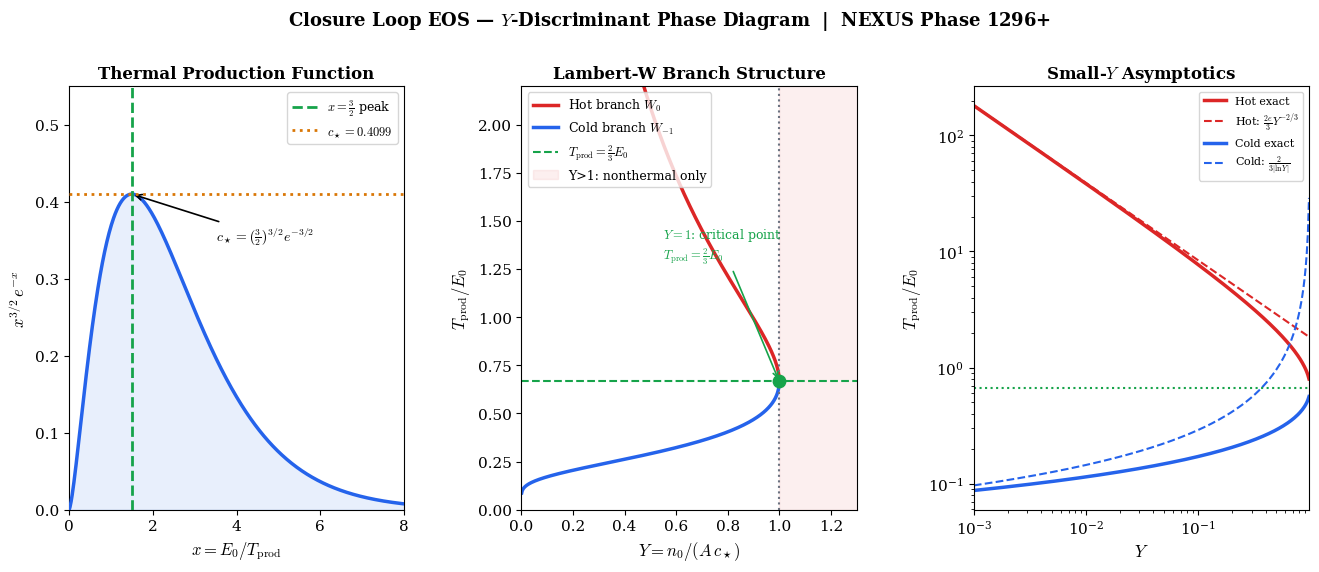

Figure saved to /tmp/Y_phase_diagram.png


In [6]:
# ── Full phase diagram ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.subplots_adjust(wspace=0.35)

C0 = '#2563EB'; C1 = '#DC2626'; C2 = '#16A34A'; C3 = '#D97706'; Cg = '#6B7280'

# ── Left: thermal production function ─────────────────────────────────────────
ax = axes[0]
x_arr = np.linspace(0.01, 8, 600)
f_arr = x_arr**1.5 * np.exp(-x_arr)

ax.plot(x_arr, f_arr, color=C0, lw=2.5, zorder=3)
ax.fill_between(x_arr, f_arr, alpha=0.10, color=C0)
ax.axvline(1.5, color=C2, ls='--', lw=2, label=r'$x=\frac{3}{2}$ peak', zorder=4)
ax.axhline(c_star, color=C3, ls=':', lw=2, label=rf'$c_\star={c_star:.4f}$', zorder=4)

# Annotate peak
ax.annotate(r'$c_\star = \left(\frac{3}{2}\right)^{3/2}e^{-3/2}$',
            xy=(1.5, c_star), xytext=(3.5, 0.35),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            fontsize=10)
ax.set_xlabel(r'$x = E_0 / T_{\rm prod}$', fontsize=12)
ax.set_ylabel(r'$x^{3/2}\,e^{-x}$', fontsize=12)
ax.set_title('Thermal Production Function', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 8); ax.set_ylim(0, 0.55)

# ── Middle: Lambert-W phase diagram ────────────────────────────────────────────
ax = axes[1]
Y_arr = np.linspace(0.001, 0.9999, 600)
T_hot_arr  = np.array([1/x_hot(Y)  for Y in Y_arr])
T_cold_arr = np.array([1/x_cold(Y) for Y in Y_arr])

ax.plot(Y_arr, T_hot_arr,  color=C1, lw=2.5, label=r'Hot branch $W_0$')
ax.plot(Y_arr, T_cold_arr, color=C0, lw=2.5, label=r'Cold branch $W_{-1}$')
ax.axvline(1.0, color=Cg, ls=':', lw=1.5)
ax.axhline(2/3, color=C2, ls='--', lw=1.5, label=r'$T_\mathrm{prod}=\frac{2}{3}E_0$')

# Shade regions
ax.fill_betweenx([0, 5], 1, 1.5, alpha=0.07, color=C1, label='Y>1: nonthermal only')

# Mark critical point
ax.scatter([1.0], [2/3], s=80, color=C2, zorder=5)
ax.annotate(r'$Y=1$: critical point'+"\n"+r'$T_{\rm prod}=\frac{2}{3}E_0$',
            xy=(1.0, 2/3), xytext=(0.55, 1.3),
            arrowprops=dict(arrowstyle='->', color=C2, lw=1.2), fontsize=9,
            color=C2)

ax.set_xlabel(r'$Y = n_0 / (A\,c_\star)$', fontsize=12)
ax.set_ylabel(r'$T_{\rm prod} / E_0$', fontsize=12)
ax.set_title('Lambert-W Branch Structure', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0, 1.3); ax.set_ylim(0, 2.2)

# ── Right: asymptotic behavior ────────────────────────────────────────────────
ax = axes[2]
Y_small = np.logspace(-3, -0.01, 300)
T_hot_ex   = np.array([1/x_hot(Y)  for Y in Y_small])
T_cold_ex  = np.array([1/x_cold(Y) for Y in Y_small])
T_hot_as   = (2*np.e/3) * Y_small**(-2/3)
T_cold_as  = 2 / (3 * np.abs(np.log(Y_small)))

ax.loglog(Y_small, T_hot_ex,  color=C1, lw=2.5, label=r'Hot exact')
ax.loglog(Y_small, T_hot_as,  color=C1, lw=1.5, ls='--', label=r'Hot: $\frac{2e}{3}Y^{-2/3}$')
ax.loglog(Y_small, T_cold_ex, color=C0, lw=2.5, label=r'Cold exact')
ax.loglog(Y_small, T_cold_as, color=C0, lw=1.5, ls='--', label=r'Cold: $\frac{2}{3|\ln Y|}$')
ax.axhline(2/3, color=C2, ls=':', lw=1.5)

ax.set_xlabel(r'$Y$', fontsize=12)
ax.set_ylabel(r'$T_{\rm prod} / E_0$', fontsize=12)
ax.set_title(r'Small-$Y$ Asymptotics', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(Y_small[0], Y_small[-1])

fig.suptitle(r'Closure Loop EOS — $Y$-Discriminant Phase Diagram  |  NEXUS Phase 1296+',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig('Y_phase_diagram.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved to /tmp/Y_phase_diagram.png')

---
## 6. Jüttner EOS (exact Synge result)

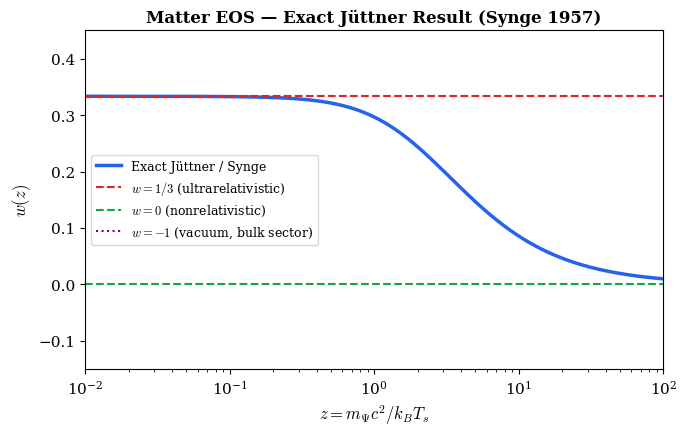

In [7]:
# ── Jüttner EOS w(z) ───────────────────────────────────────────────────────────
def w_juettner(z):
    """Exact EOS parameter from Maxwell-Jüttner / Synge (1957).
    z = m_ψ c² / k_B T_s
    Limits: w→1/3 as z→0 (UR), w→0 as z→∞ (NR)
    """
    K1 = kv(1, z)
    K2 = kv(2, z)
    return 1.0 / (z * K1 / K2 + 3)

fig, ax = plt.subplots(figsize=(7, 4.5))
z_arr = np.logspace(-2, 2, 500)
w_arr = np.array([w_juettner(z) for z in z_arr])

ax.semilogx(z_arr, w_arr, color=C0, lw=2.5, label='Exact Jüttner / Synge')
ax.axhline(1/3, color=C1, ls='--', lw=1.5, label=r'$w=1/3$ (ultrarelativistic)')
ax.axhline(0,   color=C2, ls='--', lw=1.5, label=r'$w=0$ (nonrelativistic)')
ax.axhline(-1,  color='purple', ls=':', lw=1.5, label=r'$w=-1$ (vacuum, bulk sector)')

ax.set_xlabel(r'$z = m_\Psi c^2 / k_B T_s$', fontsize=12)
ax.set_ylabel(r'$w(z)$', fontsize=12)
ax.set_title('Matter EOS — Exact Jüttner Result (Synge 1957)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.15, 0.45)
ax.set_xlim(z_arr[0], z_arr[-1])
plt.tight_layout()
plt.show()

---
## 7. The Single Remaining Calculation

The entire open frontier reduces to inserting two numbers:

$$n_0 = \frac{\Lambda_{\rm eff}}{\kappa\,\Lambda_0\,V_0}, \qquad A = g\,T_0^3\left(\frac{m_\Psi}{2\pi E_0}\right)^{3/2}$$

then computing:

$$Y = \frac{n_0}{A\,c_\star}$$

The branch structure then tells the full story.

In [8]:
# ── Y-discriminant solver (template for parameter insertion) ──────────────────

def compute_Y_and_branches(Lambda_eff, Lambda_0_val, R_0, m_psi, E_0, T_0_K, g=1):
    """
    Given the theory parameters, compute Y and return the full branch analysis.

    Parameters
    ----------
    Lambda_eff  : float  effective cosmological constant (m⁻²)
    Lambda_0_val: float  bulk energy density parameter (J/m³)
    R_0         : float  equilibrium loop radius (m)
    m_psi       : float  loop mass-equivalent (kg)
    E_0         : float  loop rest energy = m_psi c² (J)
    T_0_K       : float  present-day CMB temperature (K)
    g           : int    internal degrees of freedom (default 1)

    Returns
    -------
    dict with Y, branch classification, and T_prod values
    """
    kappa_val = 8 * np.pi * G / c_SI**4
    V_0 = (4*np.pi/3) * R_0**3

    # Present-day loop density
    n_0 = Lambda_eff / (kappa_val * Lambda_0_val * V_0)

    # Thermal prefactor
    T_0_J = kB * T_0_K   # T_0 in energy units
    A = g * T_0_J**3 * (m_psi / (2 * np.pi * E_0))**1.5

    # Normalized abundance
    Y_val = n_0 / (A * c_star)

    result = {
        'n_0': n_0,
        'A': A,
        'Y': Y_val,
        'c_star': c_star,
    }

    if Y_val > 1:
        result['branch'] = 'NONTHERMAL (Y > 1)'
        result['T_prod_hot']  = None
        result['T_prod_cold'] = None
        result['note'] = 'Required: Kibble / reheating / pre-bounce production'
    elif np.isclose(Y_val, 1.0, rtol=1e-4):
        result['branch'] = 'CRITICAL THERMAL (Y = 1)'
        result['T_prod_hot']  = (2/3) * E_0
        result['T_prod_cold'] = (2/3) * E_0
        result['note'] = 'Unique: T_prod = (2/3) E_0 — optimal threshold production'
    else:
        xh = x_hot(Y_val)
        xc = x_cold(Y_val)
        result['branch']      = f'TWO THERMAL BRANCHES (Y = {Y_val:.4f} < 1)'
        result['T_prod_hot']  = E_0 / xh
        result['T_prod_cold'] = E_0 / xc
        result['x_hot']       = xh
        result['x_cold']      = xc
        result['note']        = 'Both branches viable; dynamics selects one'

    return result


# ── Example with Planck-scale parameters ─────────────────────────────────────
print('=== TEMPLATE RUN (Planck-scale parameters) ===')
print('Awaiting: actual E_0, m_psi, R_0 from loop radius calculation')
print()
print('Once those are known, call compute_Y_and_branches() to close the frontier.')
print()
print('Phase diagram rules:')
print(f'  Y > 1   → nonthermal relic required')
print(f'  Y = 1   → critical thermal: T_prod = (2/3) E_0 exactly')
print(f'  0<Y<1   → two thermal branches')
print(f'         hot:  T_prod/E_0 = -2 / [3 W_0(-e^-1 Y^2/3)]')
print(f'         cold: T_prod/E_0 = -2 / [3 W_{{-1}}(-e^-1 Y^2/3)]')

=== TEMPLATE RUN (Planck-scale parameters) ===
Awaiting: actual E_0, m_psi, R_0 from loop radius calculation

Once those are known, call compute_Y_and_branches() to close the frontier.

Phase diagram rules:
  Y > 1   → nonthermal relic required
  Y = 1   → critical thermal: T_prod = (2/3) E_0 exactly
  0<Y<1   → two thermal branches
         hot:  T_prod/E_0 = -2 / [3 W_0(-e^-1 Y^2/3)]
         cold: T_prod/E_0 = -2 / [3 W_{-1}(-e^-1 Y^2/3)]


---
## 8. Hot / Cold Nibble Runtime — Connection to SHA-256 Work

The nibble-growth model in `hot_cold_nibble_runtime_notebook.ipynb` is structurally parallel:

| Closure EOS | SHA-256 Nibble Model |
|---|---|
| $Y$ = normalized abundance | Heat = local branching entropy |
| $Y > 1$ → nonthermal | Hot frontier → multiple continuations |
| $Y = 1$ → critical | Nyquist-exact carry constraint |
| $Y < 1$ → two thermal branches | Cold crystallization / cooling |
| Lambert-$W$ inversion | GF(2) Jacobian rank structure |
| 36-dim null space | Remaining underdetermined nibble slots |

In both systems: **the open question is whether additional constraints reduce the branch count to one.**

---
## 9.  Researcher Correction — Y as Prediction vs Consistency Test

Y is only a true prediction if $n_0$ and $A$ are independently fixed by the theory. The document correctly states "compute $n_0$, compute $A$, form $Y$." But whether this constitutes a *prediction* or a *consistency check* depends on whether:

- $(\Lambda_{\rm eff},\, \Lambda_0,\, R_0)$ fixing $n_0$
- and $(g,\, m_\Psi,\, E_0)$ fixing $A$

are already locked **independently** by the same parameter set, or whether $(g, m_\Psi, E_0)$ still carry model freedom.

The last real meta-question:

$$\boxed{\text{Are }m_\Psi,\ E_0,\ g\text{ derived outputs, or tunable inputs?}}$$

If they are **derived** → $Y$ is a true model prediction.  
If **not** → $Y$ is a reduced consistency test.

That is the only conceptual caution to keep alive.


---
## 10.  Branch Structure and Fine-Tuning Asymmetry

The branch logic is now right, and neither branch is selected in advance:

- $W_0$: **hot branch**
- $W_{-1}$: **cold branch**

The small-$Y$ asymptotics tell something physically important:

$$\boxed{\text{If }Y \ll 1,\text{ the hot branch becomes violently fine-tuned much faster than the cold branch.}}$$

- **Hot branch** diverges as $Y^{-2/3}$: production must occur at $T \gg E_0$. Extremely fine-tuned.
- **Cold branch** falls only as $1/|\ln Y|$: production at $T \ll E_0$. Far less severely fine-tuned.

So unless the eventual numbers land near the critical point ($Y \approx 1$), the cold branch is the less pathological thermal option.


---
## 11. Final Status Table



In [9]:
status = [
    ('Einstein-class macro geometry',           'THEOREM',            'Lovelock uniqueness in 4D'),
    ('Dual-null source split',                  'THEOREM',            'Exact metric variation of S[Ψ]'),
    ('Minimal dual action S_NG + S_bulk',        'THEOREM',            'Gauss-Bonnet + (l_s/R_s)² suppression'),
    ('Jüttner matter EOS w(z)',                  'THEOREM',            'Exact Synge 1957 Bessel result'),
    ('Vacuum EOS w = −1',                        'CLOSED',             'Symmetry + dynamical bulk routes'),
    ('Λ_eff constancy',                          'CLOSED',             'Bianchi + μ_loop = 0'),
    ('C.4 mode spectrum / Hagedorn',             'EFFECTIVELY CLOSED', 'Leading-order asymptotic fix'),
    ('B.4 bounce exponent S_bounce',             'DERIVED',            '(16π/3)σ_T³/Λ₀²; numerically verified'),
    ('I-condition: S_bounce > 140',              'NEW THEOREM',        'Loop persistence bound from primitive I'),
    ('Path 1 (A_fluct)',                         'DEMOTED',            'log(A)=O(1) vs S~10^256'),
    ('Path 3 (S~1 window)',                      'DEMOTED',            'I-condition: τ_loop ~ t_Pl'),
    ('Ceiling constant c★ = (3/2)^(3/2)e^(-3/2)', 'DERIVED',          f'{c_star:.6f}'),
    ('Y-discriminant formulation',               'NEW THIS SESSION',   'Y = n₀/(A c★) = single state variable'),
    ('Simplified Lambert-W form',                'NEW THIS SESSION',   'x± = -(3/2) W_{0,-1}(-e^{-1} Y^{2/3})'),
    ('Population origin n_0',                    'OPEN — SOLE FRONTIER', 'Compute n_0 and A; evaluate Y'),
]

print(f"{'Claim':<45} {'Status':<22} {'Note'}")
print('='*110)
for claim, status_str, note in status:
    print(f"{claim:<45} {status_str:<22} {note}")

Claim                                         Status                 Note
Einstein-class macro geometry                 THEOREM                Lovelock uniqueness in 4D
Dual-null source split                        THEOREM                Exact metric variation of S[Ψ]
Minimal dual action S_NG + S_bulk             THEOREM                Gauss-Bonnet + (l_s/R_s)² suppression
Jüttner matter EOS w(z)                       THEOREM                Exact Synge 1957 Bessel result
Vacuum EOS w = −1                             CLOSED                 Symmetry + dynamical bulk routes
Λ_eff constancy                               CLOSED                 Bianchi + μ_loop = 0
C.4 mode spectrum / Hagedorn                  EFFECTIVELY CLOSED     Leading-order asymptotic fix
B.4 bounce exponent S_bounce                  DERIVED                (16π/3)σ_T³/Λ₀²; numerically verified
I-condition: S_bounce > 140                   NEW THEOREM            Loop persistence bound from primitive I
Path 1 (A_fluct)  

In [10]:
# ── Session fingerprint ───────────────────────────────────────────────────────
import datetime
print('='*65)
print('CLOSURE LOOP EOS — Y-DISCRIMINANT EDITION')
print('NEXUS Phase 1296+  |  Dean A. Kulik  |  QuHarmonics')
print(f'Generated: {datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")}')
print('='*65)
print()
print(f'c★  = (3/2)^(3/2) × e^(-3/2) = {c_star:.8f}')
print(f'I-condition bound = {I_bound:.2f}')
print(f'S_bounce (physical) = 10^{np.log10(S_bounce):.1f}')
print()
print('THE FRONTIER:')
print('  Compute n₀ = Λ_eff / (κ Λ₀ V₀)')
print('  Compute A  = g T₀³ (m_ψ / 2π E₀)^(3/2)')
print('  Compute Y  = n₀ / (A c★)')
print('  Y > 1  → nonthermal relic')
print('  Y = 1  → T_prod = (2/3) E₀ (critical thermal)')
print('  Y < 1  → T_prod = E₀ / [-(3/2) W_{0,-1}(-e^{-1} Y^{2/3})]')

CLOSURE LOOP EOS — Y-DISCRIMINANT EDITION
NEXUS Phase 1296+  |  Dean A. Kulik  |  QuHarmonics
Generated: 2026-04-23 00:41 UTC

c★  = (3/2)^(3/2) × e^(-3/2) = 0.40991628
I-condition bound = 140.24
S_bounce (physical) = 10^256.4

THE FRONTIER:
  Compute n₀ = Λ_eff / (κ Λ₀ V₀)
  Compute A  = g T₀³ (m_ψ / 2π E₀)^(3/2)
  Compute Y  = n₀ / (A c★)
  Y > 1  → nonthermal relic
  Y = 1  → T_prod = (2/3) E₀ (critical thermal)
  Y < 1  → T_prod = E₀ / [-(3/2) W_{0,-1}(-e^{-1} Y^{2/3})]
